# Imports

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt


## Path settings

In [20]:
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

Current directory: C:\Users\HP\OneDrive - Higher Education Commission\MHdatabase\AQI_prediction_system\EDA


In [21]:
file_path = os.path.join(os.path.dirname(current_dir), 'data', 'combined_air_weather_5_cities.csv')

In [22]:
print(f"File path: {file_path}")

File path: C:\Users\HP\OneDrive - Higher Education Commission\MHdatabase\AQI_prediction_system\data\combined_air_weather_5_cities.csv


In [23]:
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"DataFrame loaded successfully! Shape: {df.shape}")
    print(df.head())
else:
    print(f"File not found at: {file_path}")

DataFrame loaded successfully! Shape: (87720, 18)
               timestamp_utc       city  latitude  longitude  pm2_5  pm10  \
0  2024-08-02 00:00:00+00:00  Islamabad   33.6844    73.0479   30.6  43.7   
1  2024-08-02 01:00:00+00:00  Islamabad   33.6844    73.0479   31.4  44.9   
2  2024-08-02 02:00:00+00:00  Islamabad   33.6844    73.0479   37.7  54.5   
3  2024-08-02 03:00:00+00:00  Islamabad   33.6844    73.0479   40.5  59.4   
4  2024-08-02 04:00:00+00:00  Islamabad   33.6844    73.0479   37.7  56.2   

       co   no2   so2     o3  us_aqi  temperature  humidity  pressure  \
0  1235.0  32.8   0.8    0.0      80         24.8        94     941.6   
1  1134.0  33.3   3.5   22.0      80         26.2        93     940.9   
2   990.0  33.7   7.3   53.0      82         27.2        88     941.2   
3   843.0  31.5  10.4   85.0      84         28.4        82     942.0   
4   693.0  24.2  12.5  120.0      86         29.3        79     942.3   

   wind_speed  wind_direction  precipitation  cl

# EDA

## Shape, Columns, types

In [24]:
print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nData Types:")
print(df.dtypes)

DATA OVERVIEW
Shape: (87720, 18)
Columns: ['timestamp_utc', 'city', 'latitude', 'longitude', 'pm2_5', 'pm10', 'co', 'no2', 'so2', 'o3', 'us_aqi', 'temperature', 'humidity', 'pressure', 'wind_speed', 'wind_direction', 'precipitation', 'cloud_cover']

Data Types:
timestamp_utc      object
city               object
latitude          float64
longitude         float64
pm2_5             float64
pm10              float64
co                float64
no2               float64
so2               float64
o3                float64
us_aqi              int64
temperature       float64
humidity            int64
pressure          float64
wind_speed        float64
wind_direction      int64
precipitation     float64
cloud_cover         int64
dtype: object


## First 5 rows

In [25]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
               timestamp_utc       city  latitude  longitude  pm2_5  pm10  \
0  2024-08-02 00:00:00+00:00  Islamabad   33.6844    73.0479   30.6  43.7   
1  2024-08-02 01:00:00+00:00  Islamabad   33.6844    73.0479   31.4  44.9   
2  2024-08-02 02:00:00+00:00  Islamabad   33.6844    73.0479   37.7  54.5   
3  2024-08-02 03:00:00+00:00  Islamabad   33.6844    73.0479   40.5  59.4   
4  2024-08-02 04:00:00+00:00  Islamabad   33.6844    73.0479   37.7  56.2   

       co   no2   so2     o3  us_aqi  temperature  humidity  pressure  \
0  1235.0  32.8   0.8    0.0      80         24.8        94     941.6   
1  1134.0  33.3   3.5   22.0      80         26.2        93     940.9   
2   990.0  33.7   7.3   53.0      82         27.2        88     941.2   
3   843.0  31.5  10.4   85.0      84         28.4        82     942.0   
4   693.0  24.2  12.5  120.0      86         29.3        79     942.3   

   wind_speed  wind_direction  precipitation  cloud_cover  
0         2.3          

## Missing values


In [26]:
print("\nMissing values:")
print(df.isnull().sum())

timestamp_utc     0
city              0
latitude          0
longitude         0
pm2_5             0
pm10              0
co                0
no2               0
so2               0
o3                0
us_aqi            0
temperature       0
humidity          0
pressure          0
wind_speed        0
wind_direction    0
precipitation     0
cloud_cover       0
dtype: int64


## Analysis

In [27]:
print(df.describe())

## Missing columns while combining the columns and All city checks

In [28]:
missing = (
    df.isnull().sum().sort_values(ascending=False))
print(missing[missing > 0])

if 'city' in df.columns:
    print(f"\nCities in dataset: {df['city'].unique()}")

Series([], dtype: int64)

Cities in dataset: ['Islamabad' 'Rawalpindi' 'Lahore' 'Karachi' 'Peshawar']


# Target Variable Study

In [32]:
print(df["us_aqi"].describe())
print(df["us_aqi"].value_counts().head(20))

count    87720.000000
mean       115.819140
std         40.330612
min         41.000000
25%         85.000000
50%        106.000000
75%        144.000000
max        538.000000
Name: us_aqi, dtype: float64
us_aqi
82    1247
86    1223
81    1192
77    1190
85    1177
89    1168
92    1165
88    1157
76    1140
87    1136
91    1134
96    1130
99    1108
90    1100
83    1099
97    1096
79    1085
78    1078
80    1076
93    1068
Name: count, dtype: int64


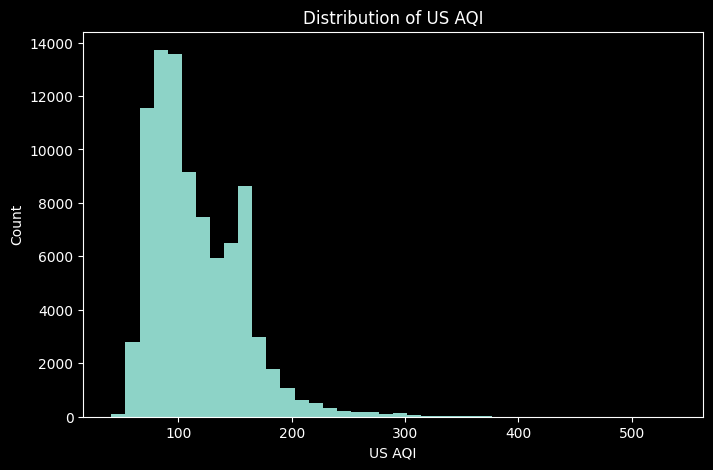

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["us_aqi"], bins=40)

plt.title("Distribution of US AQI")
plt.xlabel("US AQI")
plt.ylabel("Count")

plt.show()

## Pollutant Distributions

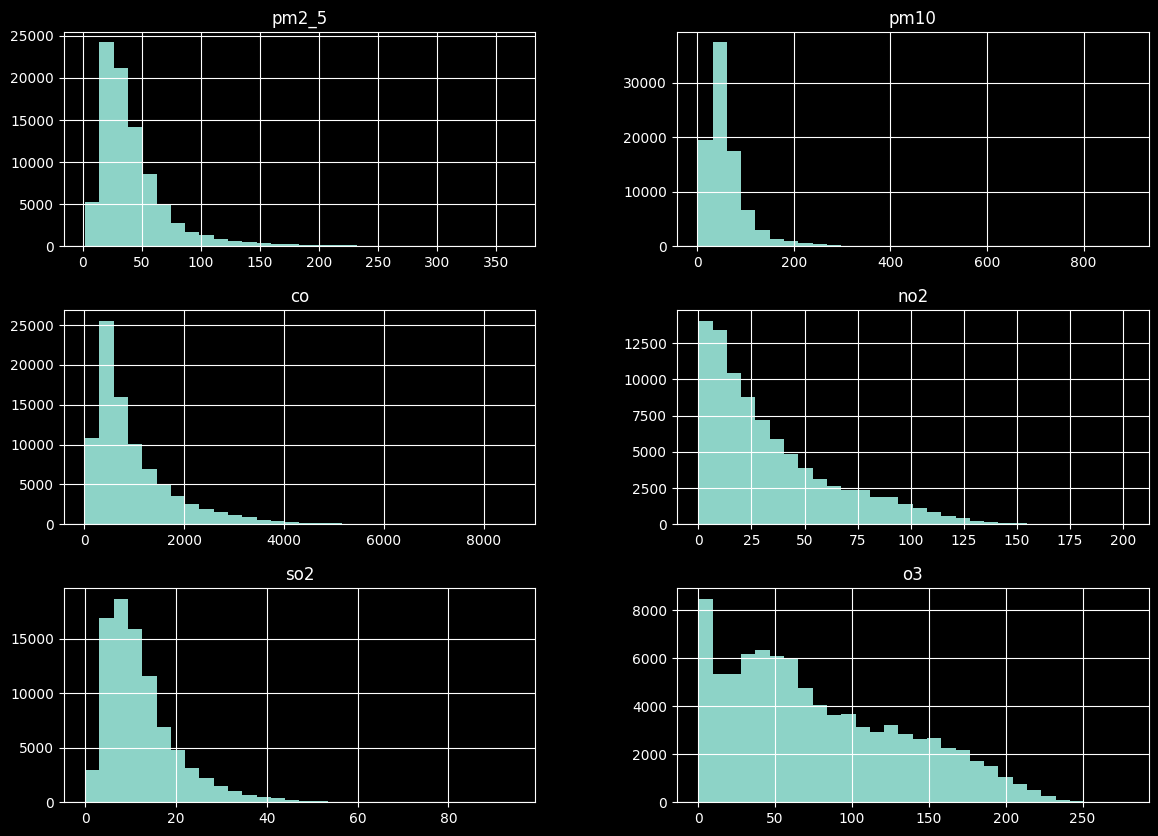

In [33]:
pollutants = [
    "pm2_5",
    "pm10",
    "co",
    "no2",
    "so2",
    "o3"
]
df[pollutants].hist(
    figsize=(14,10),
    bins=30
)

plt.show()

## Correlation Matrix

In [34]:
corr = df.select_dtypes("number").corr()

print(corr["us_aqi"].sort_values(ascending=False))

us_aqi            1.000000
pm2_5             0.711007
pm10              0.551192
so2               0.456490
co                0.438070
longitude         0.433620
no2               0.279797
latitude          0.232694
o3                0.080855
humidity          0.040527
pressure         -0.036052
precipitation    -0.040557
cloud_cover      -0.041213
wind_direction   -0.085888
temperature      -0.193647
wind_speed       -0.277130
Name: us_aqi, dtype: float64


## Correlation Graph

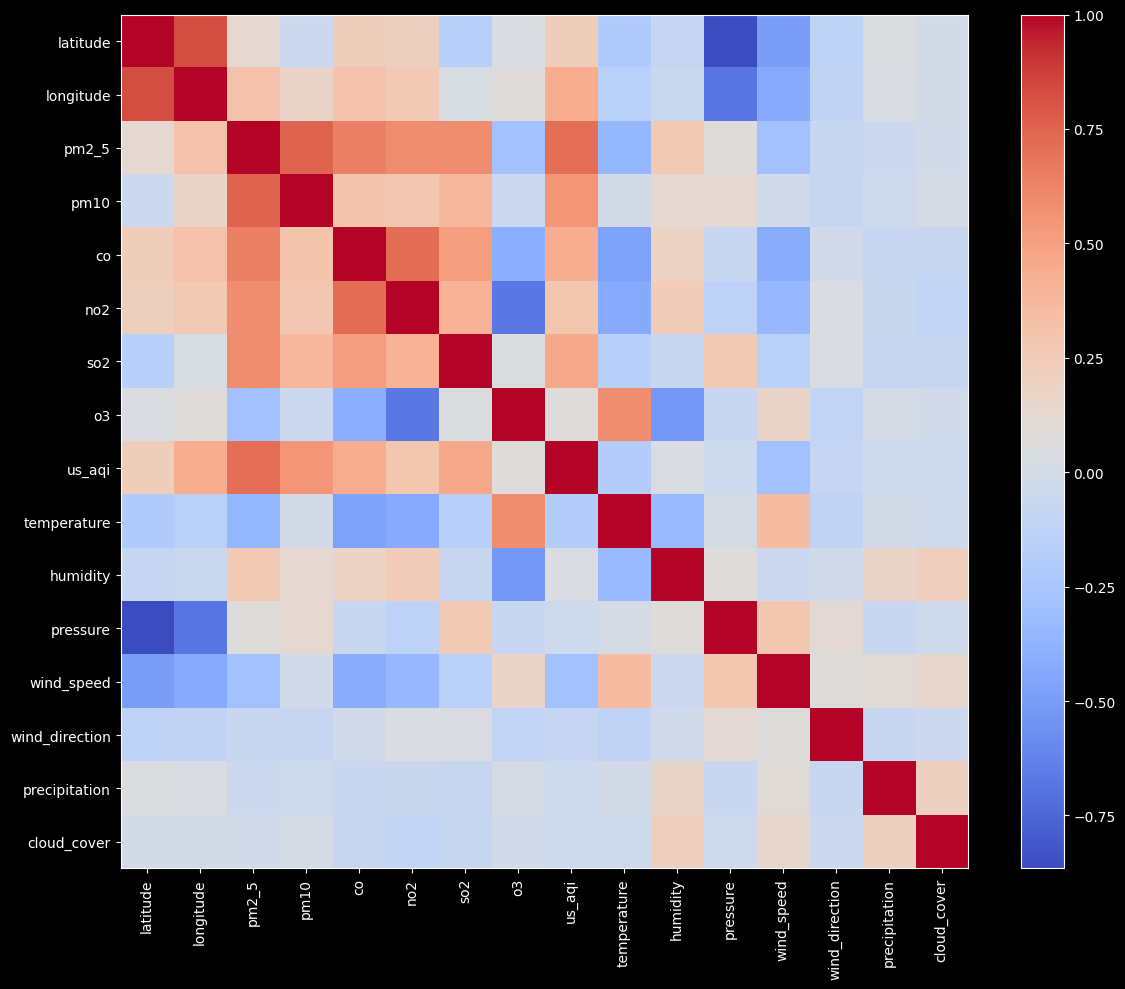

In [35]:
plt.figure(figsize=(12,10))

plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.tight_layout()
plt.show()

## AQI Over time

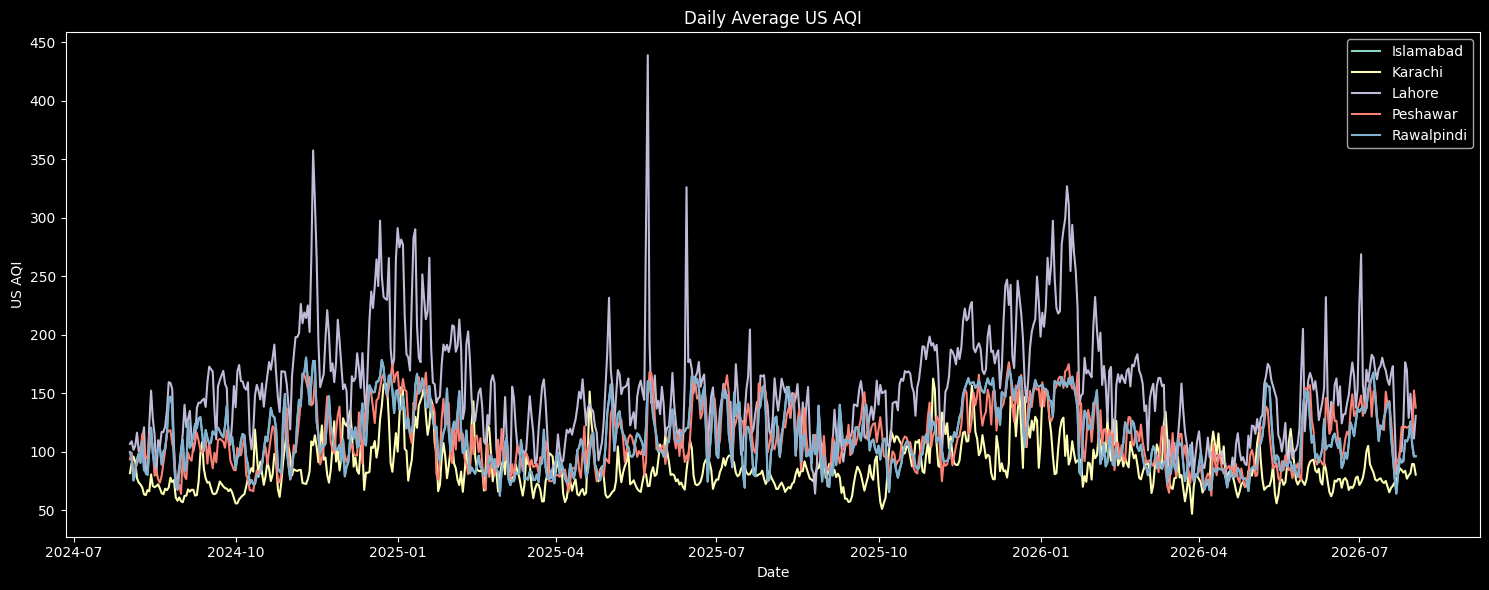

In [50]:
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

# 2. Resample daily per city
daily = (df.set_index("timestamp_utc").groupby("city")["us_aqi"].resample("D").mean().reset_index())

# 3. Plot
plt.figure(figsize=(15, 6))
for city in daily["city"].unique():
    city_data = daily[daily["city"] == city]
    plt.plot(city_data["timestamp_utc"], city_data["us_aqi"], label=city)

plt.title("Daily Average US AQI")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.legend()
plt.tight_layout()
plt.show()

## City Comparison

In [38]:
print(df.groupby("city")["us_aqi"].describe()
)

              count        mean        std   min    25%    50%    75%    max
city                                                                        
Islamabad   17544.0  112.381270  31.197646  51.0   88.0  106.0  138.0  206.0
Karachi     17544.0   88.030894  21.951465  41.0   73.0   82.0   98.0  173.0
Lahore      17544.0  154.013851  50.534718  56.0  116.0  153.0  178.0  538.0
Peshawar    17544.0  112.288418  29.727021  48.0   88.0  107.0  135.0  212.0
Rawalpindi  17544.0  112.381270  31.197646  51.0   88.0  106.0  138.0  206.0


## Hourly Pattern

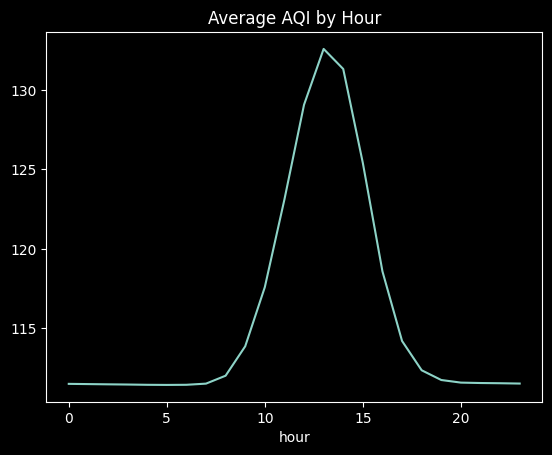

In [51]:
df["hour"] = df["timestamp_utc"].dt.hour

hourly = (df.groupby("hour")["us_aqi"].mean())

hourly.plot()

plt.title("Average AQI by Hour")

plt.show()

## Monthly Pattern

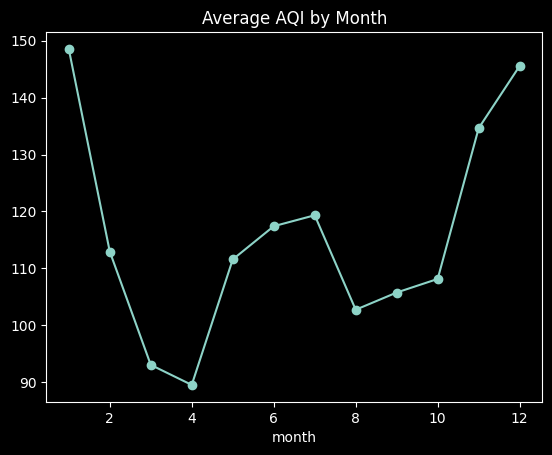

In [52]:
df["month"] = (
    df["timestamp_utc"]
    .dt.month
)

monthly = (
    df.groupby("month")["us_aqi"]
    .mean()
)

monthly.plot(marker="o")

plt.title("Average AQI by Month")

plt.show()

## AQI by city

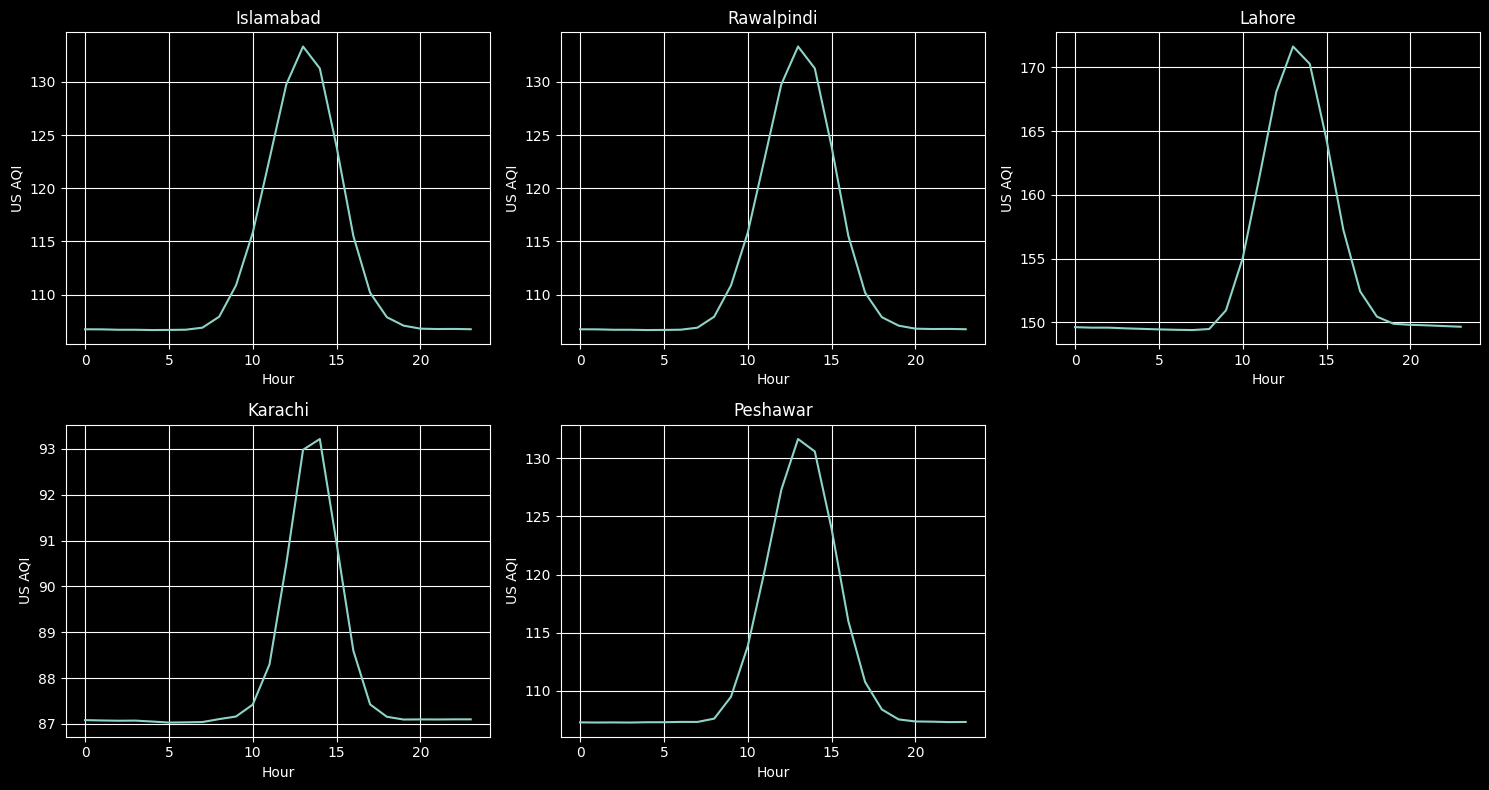

In [68]:
import matplotlib.pyplot as plt

cities = df["city"].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, city in enumerate(cities):
    hourly = (df[df["city"] == city].groupby("hour")["us_aqi"].mean())
    axes[i].plot(hourly.index, hourly.values)
    axes[i].set_title(city)
    axes[i].set_xlabel("Hour")
    axes[i].set_ylabel("US AQI")
    axes[i].grid(True)
plt.tight_layout()
plt.show()

## Hourly check to see why AQI peaks midday in all 5 Cities

In [69]:
# "Hourly analysis shows that the average US AQI reaches its maximum around 13:00–14:00 across the five cities. However, PM2.5, ozone, and wind speed peak at different times of the day, indicating that AQI variations are likely influenced by the combined effect of multiple pollutants and meteorological conditions rather than a single factor." mention in report
hourly = df.groupby("hour")[["pm2_5", "o3", "wind_speed", "us_aqi"]].mean()
print(hourly)

          pm2_5          o3  wind_speed      us_aqi
hour                                               
0     39.433762   45.847606    6.035185  111.492750
1     38.645089   46.674419    6.007770  111.478249
2     41.293653   48.887278    5.942408  111.464022
3     43.874720   58.170725    6.089904  111.451163
4     42.068290   81.285636    6.042298  111.433653
5     37.996224  111.629001    6.202599  111.426265
6     34.304022  135.480985    6.927907  111.434200
7     32.089658  148.125855    7.536498  111.507524
8     30.680766  154.249521    8.070643  112.006566
9     29.845253  154.352120    8.541204  113.859918
10    29.440711  148.029822    8.774145  117.583858
11    30.219863  135.685363    8.703475  123.106430
12    35.035759  116.740903    8.449466  129.071956
13    42.356936   95.408208    7.948181  132.589603
14    49.986101   65.921751    7.388098  131.325308
15    55.405280   43.279891    6.998331  125.405472
16    58.088482   34.389330    6.602818  118.579754
17    59.226

In [70]:
for city in df["city"].unique():
    hourly = (
        df[df["city"] == city]
        .groupby("hour")[["us_aqi", "pm2_5", "o3", "wind_speed"]]
        .mean()
    )

    print(f"\n{city}")
    print(hourly)


Islamabad
          us_aqi      pm2_5          o3  wind_speed
hour                                               
0     106.738714  30.631190   50.901505    5.804788
1     106.731874  29.146922   51.485636    5.657729
2     106.694938  31.392339   53.354309    5.542271
3     106.693570  34.122982   62.151847    5.546238
4     106.667579  33.996306   84.333789    5.317373
5     106.679891  31.470862  113.530780    5.382627
6     106.699042  28.575923  136.659371    6.410397
7     106.890561  27.746922  149.552668    7.111491
8     107.923393  27.490834  156.307798    7.528591
9     110.857729  27.395075  156.370725    7.888782
10    115.813953  27.492202  148.865937    7.861560
11    122.753762  28.579070  134.708618    7.555677
12    129.755130  32.836389  112.138167    7.473871
13    133.328317  41.132969   89.424077    7.428591
14    131.270862  49.222572   58.067031    7.174555
15    123.916553  54.982900   34.190150    6.947059
16    115.522572  57.834473   25.352941    6.655540
1

## Absolute Correlation

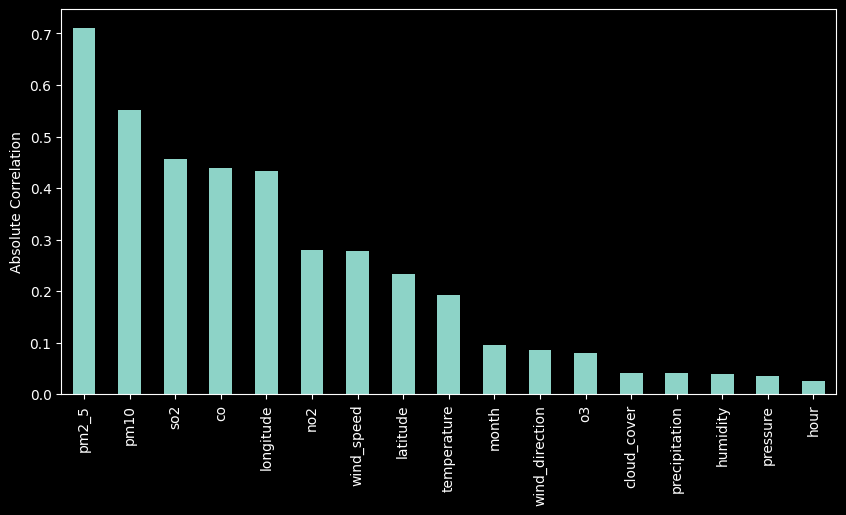

In [65]:
corr = (
    df.corr(numeric_only=True)["us_aqi"]
    .drop("us_aqi")
    .abs()
    .sort_values(ascending=False)
)

corr.plot.bar(figsize=(10,5))

plt.ylabel("Absolute Correlation")

plt.show()

## Checking whether Islamabad and Rawalpindi have same data?

In [71]:
# This is important because it can cause bias when the data is essentially the same, so we must remove one city if the follwoing code return true
cols = ["timestamp_utc", "us_aqi", "pm2_5", "o3"]

same = (
    df[df["city"] == "Islamabad"][cols]
    .reset_index(drop=True)
    .equals(
        df[df["city"] == "Rawalpindi"][cols]
        .reset_index(drop=True)
    )
)

print(same)

True


## Checking whether the weahter data is same of RWP and ISB

In [75]:
weather_cols = [
    "temperature",
    "humidity",
    "pressure",
    "wind_speed",
    "wind_direction",
    "precipitation",
    "cloud_cover"
]

for col in weather_cols:
    same = (
        df[df.city=="Islamabad"][col].reset_index(drop=True)
        .equals(
            df[df.city=="Rawalpindi"][col].reset_index(drop=True)
        )
    )
    print(col, same)

# The air-quality dataset exhibited nearly identical AQI values for Islamabad and Rawalpindi, likely due to the spatial resolution of the underlying gridded air-quality model. Weather variables, however, differed between the two locations and were retained. (explain this in the report)

temperature False
humidity False
pressure False
wind_speed False
wind_direction False
precipitation False
cloud_cover False


## Autocorrelation (important because it helps us understand whether the previous AQI affects the new)

In [74]:
for lag in [1, 3, 6, 12, 24]:
    print(f"Lag {lag}:",
          df["us_aqi"].autocorr(lag))
  # AQI at 2 PM today is more similar to AQI at 2 PM yesterday than it is to AQI at 2 AM.

Lag 1: 0.9889523413954243
Lag 3: 0.9306990432925707
Lag 6: 0.8542298466782416
Lag 12: 0.7999865394973505
Lag 24: 0.8434454448931217
